# Battery Energy Flow Forecast Notebook

Build a daily 24h (UTC, 15-minute) dispatch schedule for PV, battery, and grid.
The notebook is designed to be easy to change: edit the parameter cell, then rerun from top.

## Notebook Roadmap

1. Define input contract and create a demo input (until real table is provided).
2. Define editable battery and market parameters.
3. Validate and normalize input data.
4. Run rule-based dispatch (transparent baseline).
5. Optionally run LP optimization to minimize daily cost.
6. Reschedule remaining intervals when forecasts change.
7. Export the final forecasting table.

In [42]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", 200) # Allow displaying all columns in DataFrames without truncation.
pd.set_option("display.width", 200) # Set display width to prevent line breaks in DataFrame display. Adjust as needed for your screen size.

## Plot function to visualize the df in any step.

In [43]:
def plot_step_dataframe(
    df: pd.DataFrame,
    params: dict | None = None,
    title: str = "Dispatch / Forecast Overview",
    timestamp_col: str = "utc_timestamp",
) -> None:
    """
    Generic plot helper for notebook dataframes at any workflow step.

    It auto-detects available columns and renders:
    1) energy/flow signals, 2) SoC (if available), 3) cost trajectory (if available).
    """
    plot_df = df.copy()

    has_time_axis = timestamp_col in plot_df.columns
    if has_time_axis:
        plot_df[timestamp_col] = pd.to_datetime(plot_df[timestamp_col], utc=True, errors="coerce")
        if plot_df[timestamp_col].isna().any():
            raise ValueError(f"Column '{timestamp_col}' contains invalid timestamps.")
        x_axis = (plot_df[timestamp_col] - plot_df[timestamp_col].iloc[0]).dt.total_seconds() / 3600.0
        x_label = "Hour of day (UTC)"
    else:
        x_axis = np.arange(len(plot_df))
        x_label = "Row index"

    fig, (ax_flow, ax_soc, ax_cost) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(title, fontsize=13, fontweight="bold")

    flow_specs = [
        ("household_load_kwh", "Household load", "#1f77b4", "plot"),
        ("pv_generation_kwh", "PV generation", "#f4a216", "plot"),
        ("grid_to_load_kwh", "Grid to load", "#d62728", "step"),
        ("battery_to_load_kwh", "Battery to load", "#2ca02c", "step"),
        ("pv_to_battery_kwh", "PV to battery", "#17becf", "step"),
        ("grid_to_battery_kwh", "Grid to battery", "#9467bd", "step"),
        ("export_to_grid_kwh", "Export to grid", "#8c564b", "step"),
    ]

    plotted_flow_count = 0
    for col, label, color, mode in flow_specs:
        if col not in plot_df.columns:
            continue
        if mode == "step":
            ax_flow.step(x_axis, plot_df[col], where="post", linewidth=1.3, color=color, label=label)
        else:
            ax_flow.plot(x_axis, plot_df[col], linewidth=1.8, color=color, label=label)
        plotted_flow_count += 1

    if plotted_flow_count == 0:
        ax_flow.text(0.5, 0.5, "No flow columns found in this dataframe.", ha="center", va="center", transform=ax_flow.transAxes)
    ax_flow.set_ylabel("kWh per 15 min")
    ax_flow.grid(True, linestyle="--", alpha=0.35)
    if plotted_flow_count > 0:
        ax_flow.legend(loc="upper right", fontsize=8, ncol=2)

    plotted_soc = False
    if "soc_kwh" in plot_df.columns:
        ax_soc.plot(x_axis, plot_df["soc_kwh"], color="#8c564b", linewidth=2.0, label="SoC (kWh)")
        if params is not None and "soc_min_kwh" in params and "soc_max_kwh" in params:
            ax_soc.axhline(params["soc_min_kwh"], color="#888888", linestyle="--", linewidth=1.0, label="SoC min/max")
            ax_soc.axhline(params["soc_max_kwh"], color="#888888", linestyle="--", linewidth=1.0)
        ax_soc.set_ylabel("SoC (kWh)")
        plotted_soc = True
    elif "soc_percent" in plot_df.columns:
        ax_soc.plot(x_axis, plot_df["soc_percent"], color="#8c564b", linewidth=2.0, label="SoC (%)")
        ax_soc.set_ylabel("SoC (%)")
        plotted_soc = True
    else:
        ax_soc.text(0.5, 0.5, "No SoC columns found in this dataframe.", ha="center", va="center", transform=ax_soc.transAxes)
        ax_soc.set_ylabel("SoC")

    ax_soc.grid(True, linestyle="--", alpha=0.35)
    if plotted_soc:
        ax_soc.legend(loc="upper right", fontsize=8)

    plotted_cost = False
    if "cumulative_cost_cent" in plot_df.columns:
        ax_cost.plot(x_axis, plot_df["cumulative_cost_cent"], color="#9467bd", linewidth=2.0, label="Cumulative cost (cent)")
        plotted_cost = True
    elif "interval_cost_cent" in plot_df.columns:
        cumulative_cost = plot_df["interval_cost_cent"].cumsum()
        ax_cost.plot(x_axis, cumulative_cost, color="#9467bd", linewidth=2.0, label="Cumulative cost from interval_cost_cent")
        plotted_cost = True
    else:
        ax_cost.text(0.5, 0.5, "No cost columns found in this dataframe.", ha="center", va="center", transform=ax_cost.transAxes)

    ax_cost.set_xlabel(x_label)
    ax_cost.set_ylabel("cent")
    ax_cost.grid(True, linestyle="--", alpha=0.35)
    if plotted_cost:
        ax_cost.legend(loc="upper left", fontsize=8)

    if has_time_axis:
        ax_cost.xaxis.set_major_locator(mticker.MultipleLocator(3))
        ax_cost.xaxis.set_minor_locator(mticker.MultipleLocator(1))

    fig.tight_layout()
    plt.show()


## Step 1: Input Contract

Required input columns (96 rows, 15-minute UTC):
- `utc_timestamp`
- `pv_generation_kwh`
- `energy_price_buy_cent_kwh`
- `household_load_kwh`

Optional input column:
- `energy_price_sell_cent_kwh` (if missing, notebook uses a default parameter)

`INITIAL_SOC_KWH` is the measured battery SoC before running the schedule.

In [44]:
REQUIRED_INPUT_COLUMNS = [
    "utc_timestamp",
    "pv_generation_kwh",
    "energy_price_buy_cent_kwh",
    "household_load_kwh",
]

OPTIONAL_INPUT_COLUMNS = [
    "energy_price_sell_cent_kwh",
]


def make_demo_input_table(day_start_utc="2026-03-16 00:00:00+00:00"):
    timestamps = pd.date_range(day_start_utc, periods=96, freq="15min", tz="UTC")
    hour_float = timestamps.hour + (timestamps.minute / 60.0)

    pv_shape = np.sin(np.clip((hour_float - 6.0) / 12.0, 0.0, 1.0) * np.pi)
    pv_generation_kwh = np.round(np.maximum(0.0, pv_shape) * 1.6, 4)

    base_load = 0.35 + 0.08 * np.sin((hour_float / 24.0) * 2.0 * np.pi + 0.8)
    evening_peak = np.where((hour_float >= 18.0) & (hour_float <= 22.0), 0.35, 0.0)
    household_load_kwh = np.round(np.maximum(0.15, base_load + evening_peak), 4)

    buy_price = np.where(
        (hour_float >= 0.0) & (hour_float < 6.0),
        9.0,
        np.where((hour_float >= 17.0) & (hour_float < 22.0), 26.0, 15.0),
    )
    sell_price = np.full(shape=len(timestamps), fill_value=8.0)

    return pd.DataFrame(
        {
            "utc_timestamp": timestamps,
            "pv_generation_kwh": pv_generation_kwh,
            "energy_price_buy_cent_kwh": buy_price,
            "energy_price_sell_cent_kwh": sell_price,
            "household_load_kwh": household_load_kwh,
        }
    )


INPUT_TABLE_PATH = None  # Example: Path("data/daily_forecast_input.csv")
INITIAL_SOC_KWH = 6.0  # Update with measured battery SoC before scheduling

Using demo input table because INPUT_TABLE_PATH is None.
Input rows: 96


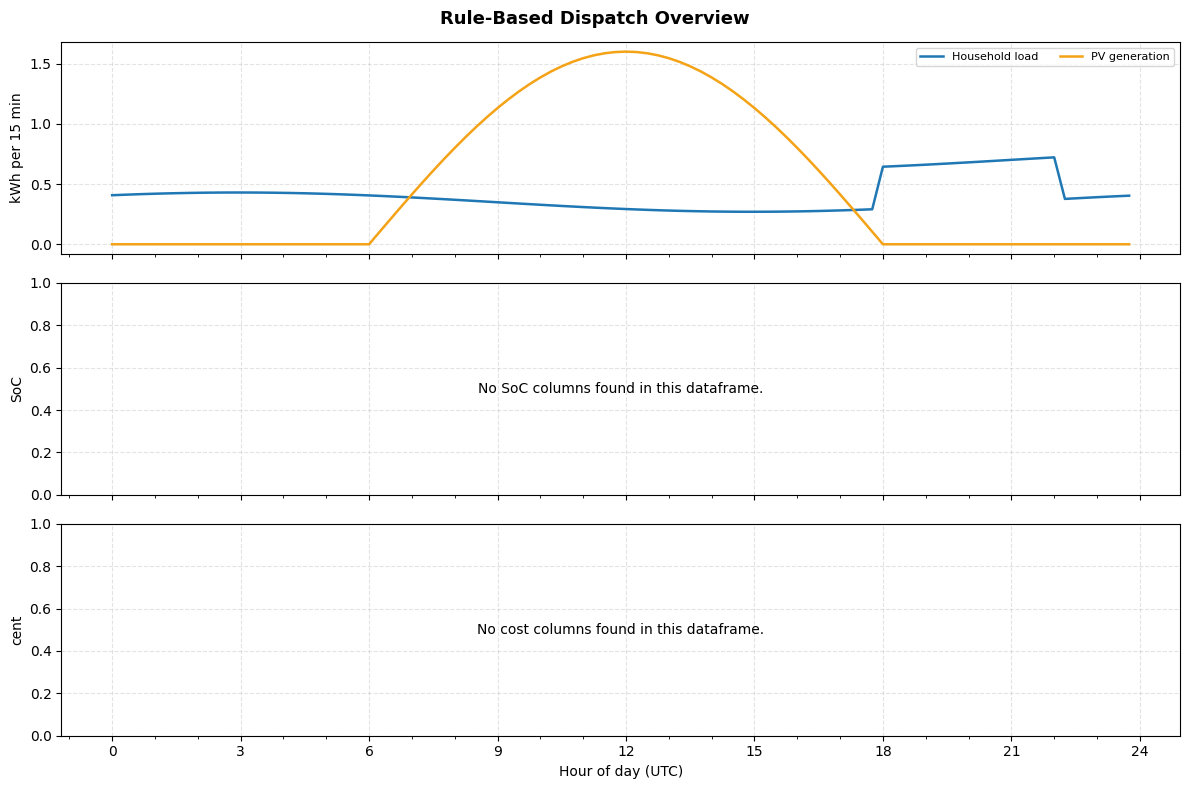

In [56]:
if INPUT_TABLE_PATH is None:
    input_forecast_df = make_demo_input_table()
    print("Using demo input table because INPUT_TABLE_PATH is None.")
else:
    input_forecast_df = pd.read_csv(INPUT_TABLE_PATH)
    print(f"Loaded input table from: {INPUT_TABLE_PATH}")

print(f"Input rows: {len(input_forecast_df)}")
input_forecast_df.head()

plot_step_dataframe(
    input_forecast_df,
    params=PARAMS,
    title="Rule-Based Dispatch Overview",
)

## Step 2: Editable Parameters

Edit this cell to change market assumptions and battery behavior.
This is the main place to tune buy/sell prices, charging/discharging losses, and power limits.

In [46]:
PARAMS = {
    "interval_minutes": 15,
    "expected_intervals": 96,
    "battery_capacity_kwh": 13.5,
    "soc_min_kwh": 1.35,
    "soc_max_kwh": 12.15,
    "max_charge_kw": 5.0,
    "max_discharge_kw": 5.0,
    "charge_efficiency": 0.96,
    "discharge_efficiency": 0.96,
    "default_sell_price_cent_kwh": 8.0, # Used if "energy_price_sell_cent_kwh" column is missing in input table.
    "allow_grid_charging": True,
    "grid_charge_price_threshold_cent_kwh": 10.0, # Only allow grid charging if buy price is below this threshold.
    "grid_import_limit_kw": None,
    "grid_export_limit_kw": None,
    "cycle_penalty_cent_per_kwh": 0.001, # Penalty to account for battery degradation cost per kWh cycled. Adjust based on battery usage preferences.
}

## Step 3: Validation And Normalization

This step enforces one clean day with 96 UTC intervals and numeric columns ready for dispatch logic.
What this cel is doing:
- Checks for 96 rows and correct timestamp format.
- Fills missing optional columns with defaults.
- Converts all numeric columns to floats for calculations.

In [47]:
def prepare_forecast_input(input_df: pd.DataFrame, params: dict) -> pd.DataFrame:
    missing_required = [col for col in REQUIRED_INPUT_COLUMNS if col not in input_df.columns]
    if missing_required:
        raise ValueError(f"Missing required input columns: {missing_required}")

    df = input_df.copy()
    df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True, errors="coerce")
    if df["utc_timestamp"].isna().any():
        bad_rows = df.index[df["utc_timestamp"].isna()].tolist()[:5]
        raise ValueError(f"Invalid utc_timestamp values at rows: {bad_rows}")

    if df["utc_timestamp"].duplicated().any():
        duplicate_count = int(df["utc_timestamp"].duplicated().sum())
        raise ValueError(f"Found {duplicate_count} duplicate utc_timestamp rows.")

    df = df.sort_values("utc_timestamp").reset_index(drop=True)

    numeric_cols = [
        "pv_generation_kwh",
        "energy_price_buy_cent_kwh",
        "household_load_kwh",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        if df[col].isna().any():
            raise ValueError(f"Column '{col}' contains NaN after numeric conversion.")

    if "energy_price_sell_cent_kwh" not in df.columns:
        df["energy_price_sell_cent_kwh"] = params["default_sell_price_cent_kwh"]
    else:
        df["energy_price_sell_cent_kwh"] = pd.to_numeric(df["energy_price_sell_cent_kwh"], errors="coerce")
        df["energy_price_sell_cent_kwh"] = df["energy_price_sell_cent_kwh"].fillna(params["default_sell_price_cent_kwh"])

    for non_negative_col in ["pv_generation_kwh", "household_load_kwh"]:
        if (df[non_negative_col] < 0).any():
            min_value = float(df[non_negative_col].min())
            raise ValueError(f"Column '{non_negative_col}' must be non-negative. Found min={min_value}")

    expected_intervals = int(params["expected_intervals"])
    if len(df) != expected_intervals:
        raise ValueError(f"Expected {expected_intervals} intervals, but got {len(df)}.")

    expected_step = pd.Timedelta(minutes=int(params["interval_minutes"]))
    wrong_step = df["utc_timestamp"].diff().dropna() != expected_step
    if wrong_step.any():
        wrong_positions = wrong_step[wrong_step].index.tolist()[:5]
        raise ValueError(f"Timestamp spacing is not 15-minute UTC at positions: {wrong_positions}")

    return df

Input table validated and normalized.


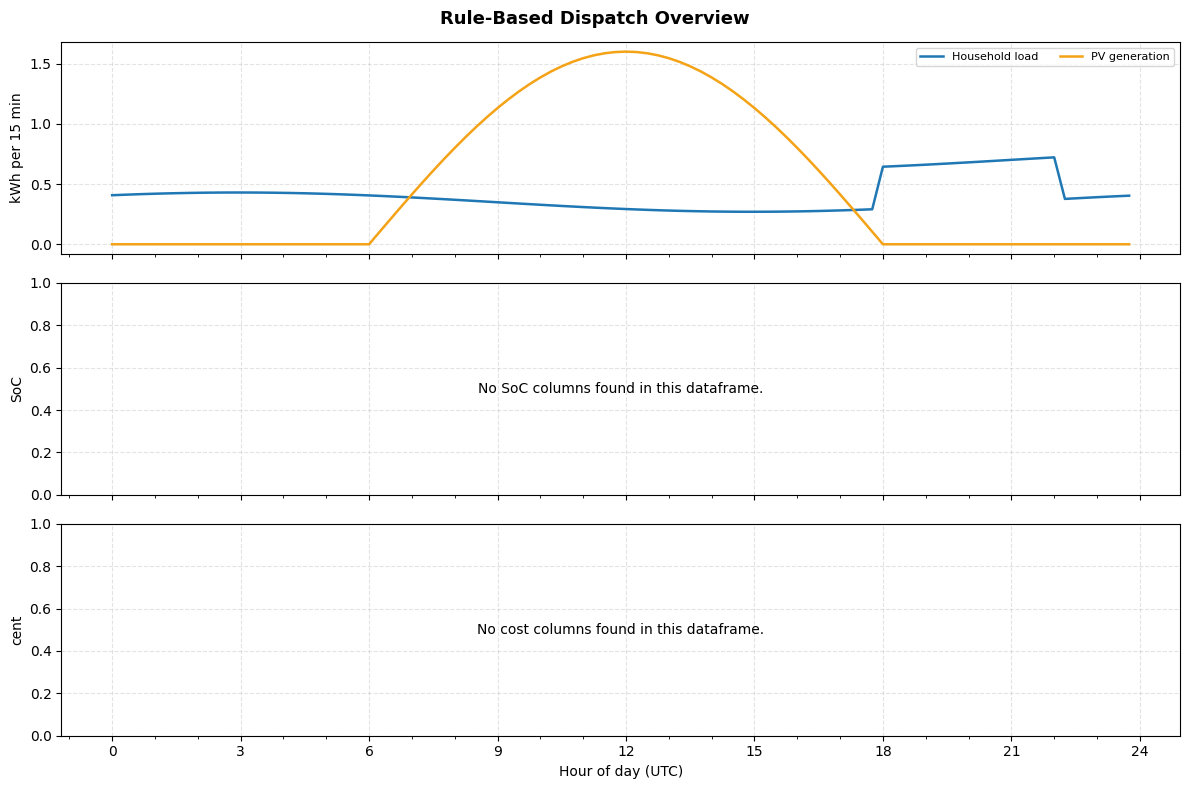

In [ ]:
prepared_forecast_df = prepare_forecast_input(input_forecast_df, PARAMS)

if not (PARAMS["soc_min_kwh"] <= INITIAL_SOC_KWH <= PARAMS["soc_max_kwh"]):
    raise ValueError(
        f"INITIAL_SOC_KWH={INITIAL_SOC_KWH} is outside [{PARAMS['soc_min_kwh']}, {PARAMS['soc_max_kwh']}]."
    )

print("Input table validated and normalized.")
prepared_forecast_df.head()

plot_step_dataframe(
    prepared_forecast_df,
    params=PARAMS,
    title="Validated Input Forecast Data",
)

## Step 4: Rule-Based Dispatch

The rule-based dispatcher follows a fixed 6-step sequence in every interval.
The numbering below is aligned 1:1 with the numbered comments in the next code cell.

1. Use PV for household load first.
2. Charge battery from remaining PV (limited by charge power and SoC headroom).
3. Discharge battery to cover remaining load (limited by discharge power and SoC floor).
4. Import grid energy for any uncovered load (limited by grid import constraint).
5. Optionally charge battery from grid when buy price is at or below the configured threshold.
6. Export remaining PV to grid; if export is capped, the remainder is tracked as curtailed PV.

In [49]:
def run_rule_dispatch(forecast_df: pd.DataFrame, params: dict, initial_soc_kwh: float) -> pd.DataFrame:
    """
    Transparent rule-based dispatcher for one forecast horizon.

    Decision order per interval (aligned with Step 4 markdown):
    1. Use PV for load.
    2. Charge battery from remaining PV.
    3. Discharge battery for remaining load.
    4. Import grid for uncovered load.
    5. Optionally charge battery from grid below threshold.
    6. Export remaining PV to grid.
    """
    dt_hours = params["interval_minutes"] / 60.0
    charge_limit_kwh = params["max_charge_kw"] * dt_hours
    discharge_limit_kwh = params["max_discharge_kw"] * dt_hours

    grid_import_limit_kw = params.get("grid_import_limit_kw")
    grid_export_limit_kw = params.get("grid_export_limit_kw")
    grid_import_limit_kwh = np.inf if grid_import_limit_kw is None else grid_import_limit_kw * dt_hours
    grid_export_limit_kwh = np.inf if grid_export_limit_kw is None else grid_export_limit_kw * dt_hours

    eta_c = params["charge_efficiency"]
    eta_d = params["discharge_efficiency"]
    soc_min = params["soc_min_kwh"]
    soc_max = params["soc_max_kwh"]
    cycle_penalty = params.get("cycle_penalty_cent_per_kwh", 0.0)

    allow_grid_charging = bool(params.get("allow_grid_charging", False))
    grid_charge_threshold = params.get("grid_charge_price_threshold_cent_kwh")

    soc = float(initial_soc_kwh)
    rows = []

    for row in forecast_df.itertuples(index=False):
        timestamp = row.utc_timestamp
        load_remaining = float(row.household_load_kwh)
        pv_remaining = float(row.pv_generation_kwh)
        buy_price = float(row.energy_price_buy_cent_kwh)
        sell_price = float(row.energy_price_sell_cent_kwh)

        # 1) Use PV generation to serve household demand first.
        pv_to_load_kwh = min(load_remaining, pv_remaining)
        load_remaining -= pv_to_load_kwh
        pv_remaining -= pv_to_load_kwh

        # 2) Charge battery with any PV surplus.
        charge_headroom_input_kwh = max(0.0, (soc_max - soc) / eta_c)
        pv_to_battery_kwh = min(pv_remaining, charge_limit_kwh, charge_headroom_input_kwh)
        soc += pv_to_battery_kwh * eta_c
        pv_remaining -= pv_to_battery_kwh

        # 3) Discharge battery to cover remaining load.
        available_discharge_to_load_kwh = max(0.0, (soc - soc_min) * eta_d)
        battery_to_load_kwh = min(load_remaining, discharge_limit_kwh, available_discharge_to_load_kwh)
        soc -= battery_to_load_kwh / eta_d
        load_remaining -= battery_to_load_kwh

        # 4) Import from grid for any load that is still uncovered.
        grid_to_load_kwh = min(load_remaining, grid_import_limit_kwh)
        load_remaining -= grid_to_load_kwh

        if load_remaining > 1e-8:
            raise ValueError(
                f"Infeasible dispatch at {timestamp}: remaining load={load_remaining:.6f} kWh. Increase grid limit, battery size, or relax constraints."
            )

        charge_limit_left_kwh = max(0.0, charge_limit_kwh - pv_to_battery_kwh)
        grid_import_left_kwh = max(0.0, grid_import_limit_kwh - grid_to_load_kwh)
        charge_headroom_input_kwh = max(0.0, (soc_max - soc) / eta_c)

        # 5) Optional grid charging in low-price intervals.
        should_grid_charge = (
            allow_grid_charging
            and grid_charge_threshold is not None
            and buy_price <= float(grid_charge_threshold)
        )

        if should_grid_charge:
            grid_to_battery_kwh = min(charge_limit_left_kwh, grid_import_left_kwh, charge_headroom_input_kwh)
        else:
            grid_to_battery_kwh = 0.0

        soc += grid_to_battery_kwh * eta_c

        # 6) Export remaining PV; any excess beyond export limit is curtailed.
        export_to_grid_kwh = min(pv_remaining, grid_export_limit_kwh)
        pv_remaining -= export_to_grid_kwh
        curtailed_pv_kwh = max(0.0, pv_remaining)

        if soc < soc_min - 1e-6 or soc > soc_max + 1e-6:
            raise ValueError(
                f"SoC out of bounds at {timestamp}: soc={soc:.6f}, bounds=[{soc_min}, {soc_max}]"
            )
        soc = float(np.clip(soc, soc_min, soc_max))

        total_import_kwh = grid_to_load_kwh + grid_to_battery_kwh
        total_export_kwh = export_to_grid_kwh
        interval_cost_cent = (
            buy_price * total_import_kwh
            - sell_price * total_export_kwh
            + cycle_penalty * (pv_to_battery_kwh + grid_to_battery_kwh + battery_to_load_kwh)
        )

        decision_tokens = []
        if pv_to_load_kwh > 1e-9:
            decision_tokens.append("pv_to_load")
        if pv_to_battery_kwh > 1e-9:
            decision_tokens.append("pv_to_battery")
        if battery_to_load_kwh > 1e-9:
            decision_tokens.append("battery_to_load")
        if grid_to_load_kwh > 1e-9:
            decision_tokens.append("grid_to_load")
        if grid_to_battery_kwh > 1e-9:
            decision_tokens.append("grid_to_battery")
        if export_to_grid_kwh > 1e-9:
            decision_tokens.append("export_to_grid")
        if not decision_tokens:
            decision_tokens.append("idle")

        rows.append(
            {
                "utc_timestamp": timestamp,
                "pv_generation_kwh": row.pv_generation_kwh,
                "household_load_kwh": row.household_load_kwh,
                "energy_price_buy_cent_kwh": buy_price,
                "energy_price_sell_cent_kwh": sell_price,
                "grid_to_load_kwh": grid_to_load_kwh,
                "pv_to_load_kwh": pv_to_load_kwh,
                "pv_to_battery_kwh": pv_to_battery_kwh,
                "battery_to_load_kwh": battery_to_load_kwh,
                "grid_to_battery_kwh": grid_to_battery_kwh,
                "export_to_grid_kwh": export_to_grid_kwh,
                "curtailed_pv_kwh": curtailed_pv_kwh,
                "soc_kwh": soc,
                "soc_percent": (soc / params["battery_capacity_kwh"]) * 100.0,
                "total_import_kwh": total_import_kwh,
                "total_export_kwh": total_export_kwh,
                "interval_cost_cent": interval_cost_cent,
                "decision_rule": " | ".join(decision_tokens),
                "method": "rule_based",
            }
        )

    output_df = pd.DataFrame(rows)
    output_df["cumulative_cost_cent"] = output_df["interval_cost_cent"].cumsum()
    return output_df

method             rule_based
daily_cost_cent       -43.452
grid_import_kwh        21.612
grid_export_kwh        33.954
final_soc_kwh            1.35
dtype: object


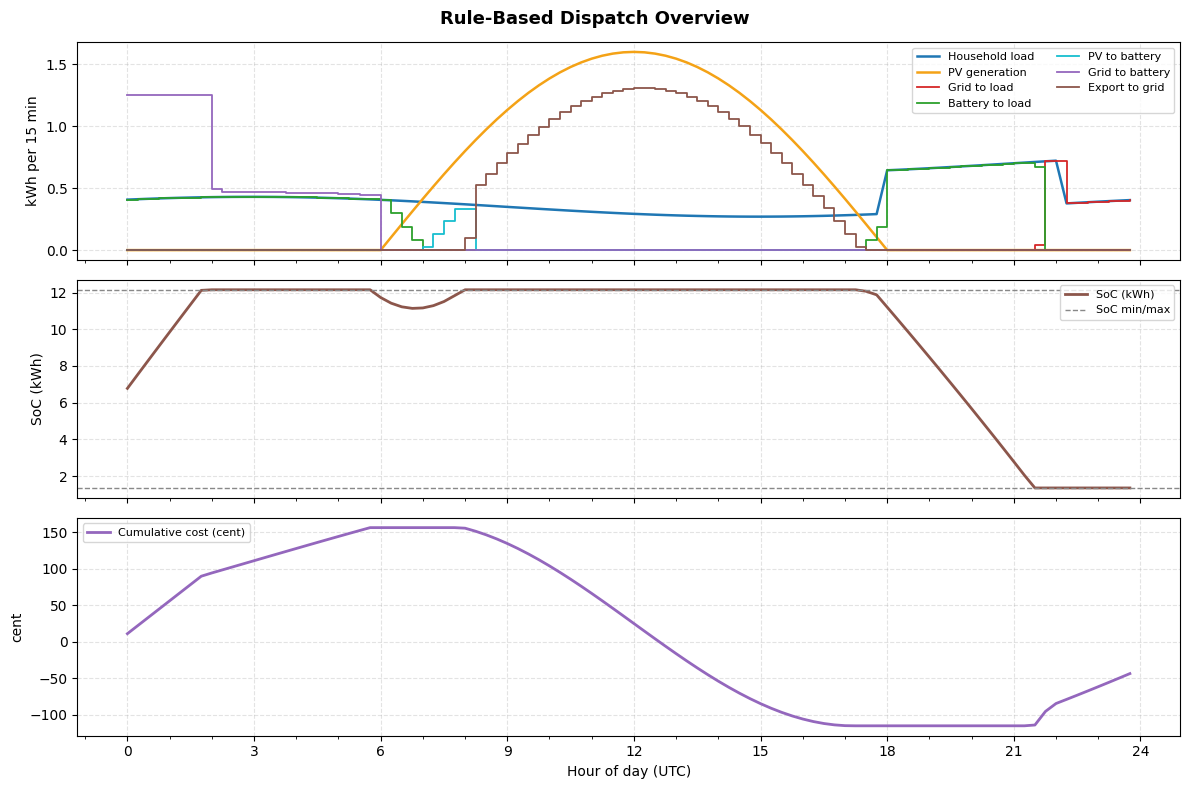

In [59]:
rule_dispatch_df = run_rule_dispatch(prepared_forecast_df, PARAMS, INITIAL_SOC_KWH)

rule_summary = pd.Series(
    {
        "method": "rule_based",
        "daily_cost_cent": round(float(rule_dispatch_df["interval_cost_cent"].sum()), 3),
        "grid_import_kwh": round(float(rule_dispatch_df["total_import_kwh"].sum()), 3),
        "grid_export_kwh": round(float(rule_dispatch_df["total_export_kwh"].sum()), 3),
        "final_soc_kwh": round(float(rule_dispatch_df["soc_kwh"].iloc[-1]), 3),
    }
)

print(rule_summary)

plot_step_dataframe(
    rule_dispatch_df,
    params=PARAMS,
    title="Rule-Based Dispatch Overview",
)

## Step 5: Optional LP Optimization

This optimization uses the same constraints as the rule-based approach and minimizes total daily cost.
If `scipy` is not available, the notebook automatically falls back to rule-based dispatch.

In [51]:
def run_lp_dispatch(forecast_df: pd.DataFrame, params: dict, initial_soc_kwh: float) -> pd.DataFrame:
    try:
        from scipy.optimize import linprog
    except Exception as exc:
        raise ImportError("scipy is required for LP optimization. Install scipy to enable this mode.") from exc

    n = len(forecast_df)
    dt_hours = params["interval_minutes"] / 60.0
    charge_limit_kwh = params["max_charge_kw"] * dt_hours
    discharge_limit_kwh = params["max_discharge_kw"] * dt_hours

    eta_c = float(params["charge_efficiency"])
    eta_d = float(params["discharge_efficiency"])
    soc_min = float(params["soc_min_kwh"])
    soc_max = float(params["soc_max_kwh"])

    if not (soc_min <= initial_soc_kwh <= soc_max):
        raise ValueError(f"Initial SoC {initial_soc_kwh} must be within [{soc_min}, {soc_max}].")

    load = forecast_df["household_load_kwh"].to_numpy(dtype=float)
    pv = forecast_df["pv_generation_kwh"].to_numpy(dtype=float)
    buy = forecast_df["energy_price_buy_cent_kwh"].to_numpy(dtype=float)
    sell = forecast_df["energy_price_sell_cent_kwh"].to_numpy(dtype=float)

    grid_import_limit_kw = params.get("grid_import_limit_kw")
    grid_export_limit_kw = params.get("grid_export_limit_kw")
    grid_import_limit_kwh = np.inf if grid_import_limit_kw is None else float(grid_import_limit_kw) * dt_hours
    grid_export_limit_kwh = np.inf if grid_export_limit_kw is None else float(grid_export_limit_kw) * dt_hours

    cycle_penalty = float(params.get("cycle_penalty_cent_per_kwh", 0.0))

    idx_gl = np.arange(0, n)
    idx_pl = np.arange(n, 2 * n)
    idx_pb = np.arange(2 * n, 3 * n)
    idx_bl = np.arange(3 * n, 4 * n)
    idx_gb = np.arange(4 * n, 5 * n)
    idx_ex = np.arange(5 * n, 6 * n)
    idx_soc = np.arange(6 * n, 7 * n + 1)
    num_vars = 7 * n + 1

    c = np.zeros(num_vars, dtype=float)
    c[idx_gl] = buy
    c[idx_gb] = buy
    c[idx_ex] = -sell
    c[idx_pb] += cycle_penalty
    c[idx_gb] += cycle_penalty
    c[idx_bl] += cycle_penalty

    A_eq_rows = []
    b_eq = []

    for t in range(n):
        row = np.zeros(num_vars, dtype=float)
        row[idx_gl[t]] = 1.0
        row[idx_pl[t]] = 1.0
        row[idx_bl[t]] = 1.0
        A_eq_rows.append(row)
        b_eq.append(load[t])

    for t in range(n):
        row = np.zeros(num_vars, dtype=float)
        row[idx_soc[t + 1]] = 1.0
        row[idx_soc[t]] = -1.0
        row[idx_pb[t]] = -eta_c
        row[idx_gb[t]] = -eta_c
        row[idx_bl[t]] = 1.0 / eta_d
        A_eq_rows.append(row)
        b_eq.append(0.0)

    A_ub_rows = []
    b_ub = []

    for t in range(n):
        row = np.zeros(num_vars, dtype=float)
        row[idx_pl[t]] = 1.0
        row[idx_pb[t]] = 1.0
        row[idx_ex[t]] = 1.0
        A_ub_rows.append(row)
        b_ub.append(pv[t])

    for t in range(n):
        row = np.zeros(num_vars, dtype=float)
        row[idx_pb[t]] = 1.0
        row[idx_gb[t]] = 1.0
        A_ub_rows.append(row)
        b_ub.append(charge_limit_kwh)

    if np.isfinite(grid_import_limit_kwh):
        for t in range(n):
            row = np.zeros(num_vars, dtype=float)
            row[idx_gl[t]] = 1.0
            row[idx_gb[t]] = 1.0
            A_ub_rows.append(row)
            b_ub.append(grid_import_limit_kwh)

    bounds = []

    for _ in range(n):
        bounds.append((0.0, None))
    for _ in range(n):
        bounds.append((0.0, None))
    for _ in range(n):
        bounds.append((0.0, charge_limit_kwh))
    for _ in range(n):
        bounds.append((0.0, discharge_limit_kwh))
    for _ in range(n):
        bounds.append((0.0, charge_limit_kwh))
    for _ in range(n):
        upper = None if not np.isfinite(grid_export_limit_kwh) else grid_export_limit_kwh
        bounds.append((0.0, upper))

    bounds.append((float(initial_soc_kwh), float(initial_soc_kwh)))
    for _ in range(n):
        bounds.append((soc_min, soc_max))

    result = linprog(
        c=c,
        A_ub=np.array(A_ub_rows, dtype=float) if A_ub_rows else None,
        b_ub=np.array(b_ub, dtype=float) if b_ub else None,
        A_eq=np.array(A_eq_rows, dtype=float),
        b_eq=np.array(b_eq, dtype=float),
        bounds=bounds,
        method="highs",
    )

    if not result.success:
        raise RuntimeError(f"LP optimization failed: {result.message}")

    x = result.x
    output_df = forecast_df.copy()
    output_df["grid_to_load_kwh"] = x[idx_gl]
    output_df["pv_to_load_kwh"] = x[idx_pl]
    output_df["pv_to_battery_kwh"] = x[idx_pb]
    output_df["battery_to_load_kwh"] = x[idx_bl]
    output_df["grid_to_battery_kwh"] = x[idx_gb]
    output_df["export_to_grid_kwh"] = x[idx_ex]
    output_df["soc_kwh"] = x[idx_soc[1:]]
    output_df["soc_percent"] = (output_df["soc_kwh"] / params["battery_capacity_kwh"]) * 100.0

    pv_used = output_df["pv_to_load_kwh"] + output_df["pv_to_battery_kwh"] + output_df["export_to_grid_kwh"]
    output_df["curtailed_pv_kwh"] = np.maximum(0.0, output_df["pv_generation_kwh"] - pv_used)

    output_df["total_import_kwh"] = output_df["grid_to_load_kwh"] + output_df["grid_to_battery_kwh"]
    output_df["total_export_kwh"] = output_df["export_to_grid_kwh"]
    output_df["interval_cost_cent"] = (
        output_df["energy_price_buy_cent_kwh"] * output_df["total_import_kwh"]
        - output_df["energy_price_sell_cent_kwh"] * output_df["total_export_kwh"]
        + cycle_penalty
        * (
            output_df["pv_to_battery_kwh"]
            + output_df["grid_to_battery_kwh"]
            + output_df["battery_to_load_kwh"]
        )
    )
    output_df["cumulative_cost_cent"] = output_df["interval_cost_cent"].cumsum()
    output_df["decision_rule"] = "optimizer_lp"
    output_df["method"] = "optimizer_lp"

    return output_df

In [52]:
def run_dispatch(
    forecast_df: pd.DataFrame,
    params: dict,
    initial_soc_kwh: float,
    use_optimizer: bool = True,
) -> pd.DataFrame:
    if use_optimizer:
        try:
            return run_lp_dispatch(forecast_df, params, initial_soc_kwh)
        except Exception as exc:
            print(f"Optimizer unavailable or failed ({exc}). Falling back to rule-based dispatch.")
    return run_rule_dispatch(forecast_df, params, initial_soc_kwh)


USE_OPTIMIZER = True
dispatch_forecast_df = run_dispatch(
    forecast_df=prepared_forecast_df,
    params=PARAMS,
    initial_soc_kwh=INITIAL_SOC_KWH,
    use_optimizer=USE_OPTIMIZER,
)

comparison_df = pd.DataFrame(
    [
        {
            "method": "rule_based",
            "daily_cost_cent": float(rule_dispatch_df["interval_cost_cent"].sum()),
            "grid_import_kwh": float(rule_dispatch_df["total_import_kwh"].sum()),
            "grid_export_kwh": float(rule_dispatch_df["total_export_kwh"].sum()),
        },
        {
            "method": dispatch_forecast_df["method"].iloc[0],
            "daily_cost_cent": float(dispatch_forecast_df["interval_cost_cent"].sum()),
            "grid_import_kwh": float(dispatch_forecast_df["total_import_kwh"].sum()),
            "grid_export_kwh": float(dispatch_forecast_df["total_export_kwh"].sum()),
        },
    ]
)

comparison_df

,method,daily_cost_cent,grid_import_kwh,grid_export_kwh
0,rule_based,-43.452458,21.611818,33.954093
1,optimizer_lp,-58.742618,10.853300,23.760300


## Step 6: Rescheduling (Remaining Day Recompute)

When a new forecast arrives, lock past intervals and recompute only the remaining horizon with the latest measured SoC.

In [53]:
def reschedule_remaining_day(
    updated_forecast_df: pd.DataFrame,
    params: dict,
    now_utc,
    actual_soc_kwh: float,
    executed_schedule_df: pd.DataFrame | None = None,
    use_optimizer: bool = True,
) -> pd.DataFrame:
    updated_prepared = prepare_forecast_input(updated_forecast_df, params)

    now_ts = pd.Timestamp(now_utc)
    if now_ts.tzinfo is None:
        now_ts = now_ts.tz_localize("UTC")
    else:
        now_ts = now_ts.tz_convert("UTC")

    past_mask = updated_prepared["utc_timestamp"] < now_ts
    future_mask = ~past_mask

    if future_mask.sum() == 0:
        raise ValueError("No future intervals available after now_utc.")

    if executed_schedule_df is not None and past_mask.any():
        locked = executed_schedule_df.copy()
        locked["utc_timestamp"] = pd.to_datetime(locked["utc_timestamp"], utc=True)
        locked = locked[locked["utc_timestamp"] < now_ts].copy()
        locked["was_rescheduled"] = False
    else:
        locked = pd.DataFrame()

    future_input = updated_prepared.loc[future_mask].reset_index(drop=True)
    future_schedule = run_dispatch(
        forecast_df=future_input,
        params=params,
        initial_soc_kwh=actual_soc_kwh,
        use_optimizer=use_optimizer,
    )
    future_schedule["was_rescheduled"] = True

    if locked.empty:
        return future_schedule.reset_index(drop=True)

    combined = pd.concat([locked, future_schedule], ignore_index=True, sort=False)
    combined = combined.sort_values("utc_timestamp").reset_index(drop=True)
    return combined


NOW_UTC = prepared_forecast_df["utc_timestamp"].iloc[48]
ACTUAL_SOC_FOR_RESCHEDULE = float(
    dispatch_forecast_df.loc[dispatch_forecast_df["utc_timestamp"] < NOW_UTC, "soc_kwh"].iloc[-1]
)

updated_forecast_df = prepared_forecast_df.copy()
updated_forecast_df.loc[
    updated_forecast_df["utc_timestamp"] >= NOW_UTC, "energy_price_buy_cent_kwh"
] *= 1.15

rescheduled_dispatch_df = reschedule_remaining_day(
    updated_forecast_df=updated_forecast_df,
    params=PARAMS,
    now_utc=NOW_UTC,
    actual_soc_kwh=ACTUAL_SOC_FOR_RESCHEDULE,
    executed_schedule_df=dispatch_forecast_df,
    use_optimizer=USE_OPTIMIZER,
)

print(f"Rescheduled from: {NOW_UTC}")
print(f"Rows marked as rescheduled: {int(rescheduled_dispatch_df['was_rescheduled'].sum())}")
rescheduled_dispatch_df.head()

Rescheduled from: 2026-03-16 12:00:00+00:00
Rows marked as rescheduled: 48


,utc_timestamp,pv_generation_kwh,energy_price_buy_cent_kwh,energy_price_sell_cent_kwh,household_load_kwh,grid_to_load_kwh,pv_to_load_kwh,pv_to_battery_kwh,battery_to_load_kwh,grid_to_battery_kwh,export_to_grid_kwh,soc_kwh,soc_percent,curtailed_pv_kwh,total_import_kwh,total_export_kwh,interval_cost_cent,cumulative_cost_cent,decision_rule,method,was_rescheduled
0,2026-03-16 00:00:00+00:00,0.0,9.0,8.0,0.4074,0.0,-0.0,0.0,0.4074,0.0,0.0,5.575625,41.300926,0.0,0.0,0.0,0.000407,0.000407,optimizer_lp,optimizer_lp,False
1,2026-03-16 00:15:00+00:00,0.0,9.0,8.0,0.4109,0.0,-0.0,0.0,0.4109,0.0,0.0,5.147604,38.130401,0.0,0.0,0.0,0.000411,0.000818,optimizer_lp,optimizer_lp,False
2,2026-03-16 00:30:00+00:00,0.0,9.0,8.0,0.4142,0.0,-0.0,0.0,0.4142,0.0,0.0,4.716146,34.934414,0.0,0.0,0.0,0.000414,0.001233,optimizer_lp,optimizer_lp,False
3,2026-03-16 00:45:00+00:00,0.0,9.0,8.0,0.4172,0.0,-0.0,0.0,0.4172,0.0,0.0,4.281562,31.715278,0.0,0.0,0.0,0.000417,0.001650,optimizer_lp,optimizer_lp,False
4,2026-03-16 01:00:00+00:00,0.0,9.0,8.0,0.4199,0.0,-0.0,0.0,0.4199,0.0,0.0,3.844167,28.475309,0.0,0.0,0.0,0.000420,0.002070,optimizer_lp,optimizer_lp,False


## Step 7: Output Forecasting Table

This table is the final schedule with flow directions and SoC.
Save path is created automatically in the `data/` folder.

In [54]:
OUTPUT_COLUMNS = [
    "utc_timestamp",
    "grid_to_load_kwh",
    "pv_to_load_kwh",
    "pv_to_battery_kwh",
    "battery_to_load_kwh",
    "grid_to_battery_kwh",
    "export_to_grid_kwh",
    "soc_kwh",
    "energy_price_buy_cent_kwh",
    "energy_price_sell_cent_kwh",
    "interval_cost_cent",
    "cumulative_cost_cent",
    "decision_rule",
    "method",
]

final_dispatch_df = dispatch_forecast_df.copy()
final_dispatch_df = final_dispatch_df[OUTPUT_COLUMNS].copy()

output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"battery_dispatch_forecast_{pd.Timestamp.utcnow():%Y%m%d_%H%M%S}.csv"
final_dispatch_df.to_csv(output_path, index=False)

daily_summary = pd.Series(
    {
        "daily_cost_cent": round(float(final_dispatch_df["interval_cost_cent"].sum()), 3),
        "daily_cost_eur": round(float(final_dispatch_df["interval_cost_cent"].sum()) / 100.0, 3),
        "final_soc_kwh": round(float(final_dispatch_df["soc_kwh"].iloc[-1]), 3),
    }
)

print(f"Saved dispatch forecast table to: {output_path}")
daily_summary

Saved dispatch forecast table to: data/battery_dispatch_forecast_20260315_125237.csv


daily_cost_cent   -58.743
daily_cost_eur     -0.587
final_soc_kwh       1.350
dtype: float64

In [55]:
def run_balance_checks(dispatch_df: pd.DataFrame, tolerance: float = 1e-6) -> pd.Series:
    load_balance_error = (
        dispatch_df["pv_to_load_kwh"]
        + dispatch_df["battery_to_load_kwh"]
        + dispatch_df["grid_to_load_kwh"]
        - dispatch_df["household_load_kwh"]
    ).abs().max()

    pv_balance_error = (
        dispatch_df["pv_to_load_kwh"]
        + dispatch_df["pv_to_battery_kwh"]
        + dispatch_df["export_to_grid_kwh"]
        + dispatch_df.get("curtailed_pv_kwh", 0.0)
        - dispatch_df["pv_generation_kwh"]
    ).abs().max()

    soc_ok = dispatch_df["soc_kwh"].between(
        PARAMS["soc_min_kwh"] - tolerance,
        PARAMS["soc_max_kwh"] + tolerance,
    ).all()

    return pd.Series(
        {
            "max_load_balance_error_kwh": float(load_balance_error),
            "max_pv_balance_error_kwh": float(pv_balance_error),
            "soc_within_bounds": bool(soc_ok),
        }
    )


run_balance_checks(dispatch_forecast_df)

max_load_balance_error_kwh     0.0
max_pv_balance_error_kwh       0.0
soc_within_bounds             True
dtype: object

## Quick Change Guide

1. Replace demo input:
   - set `INPUT_TABLE_PATH = Path("...")`
2. Update actual battery state:
   - set `INITIAL_SOC_KWH` to current measured value
3. Change market assumptions:
   - edit `default_sell_price_cent_kwh` or provide `energy_price_sell_cent_kwh` in input
4. Change charging/discharging loss:
   - edit `charge_efficiency` and `discharge_efficiency`
5. Change scheduling behavior:
   - edit `allow_grid_charging` and `grid_charge_price_threshold_cent_kwh`
6. Re-run with forecast updates:
   - use `reschedule_remaining_day(...)` with latest `actual_soc_kwh`